In [ ]:
!curl -L -o ./data/csgo-matchmaking-damage.zip https://www.kaggle.com/api/v1/datasets/download/skihikingkevin/csgo-matchmaking-damage
!unzip ./data/csgo-matchmaking-damage.zip

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Reading in the data
### It is done this way because the master dmg csv cell takes around a minute to run and would hate to have to re-run that 10+ times a sessions 

In [14]:
dmg_pt1 = pd.read_csv('../data/esea_master_dmg_demos.part1.csv')
dmg_pt2 = pd.read_csv('../data/esea_master_dmg_demos.part2.csv')

In [8]:
grenades_pt1 = pd.read_csv('../data/esea_master_grenades_demos.part1.csv')
grenades_pt2 = pd.read_csv('../data/esea_master_grenades_demos.part2.csv')

In [9]:
frags_pt1 = pd.read_csv('../data/esea_master_kills_demos.part1.csv')
frags_pt2 = pd.read_csv('../data/esea_master_kills_demos.part2.csv')

# Building the player stats PER MATCH (this needs to be aggregated)

In [ ]:
def build_player_match_stats(dmg_df, nade_df, match_col='file'):
    # -----------------------
    # TOTAL DAMAGE (all damage events from dmg_df)
    # -----------------------
    total = (
        dmg_df.groupby([match_col, 'att_id'])['hp_dmg']
        .sum()
        .reset_index()
        .rename(columns={'att_id': 'player', 'hp_dmg': 'total_raw_damage'})
    )

    # -----------------------
    # NADE DAMAGE (attacker)
    # -----------------------
    nade = (
        nade_df.groupby([match_col, 'att_id'])['hp_dmg']
        .sum()
        .reset_index()
        .rename(columns={'att_id': 'player', 'hp_dmg': 'nade_damage'})
    )

    # -----------------------
    # GUN DAMAGE = TOTAL RAW DAMAGE - NADE DAMAGE
    # -----------------------
    gun = total.merge(nade, on=[match_col, 'player'], how='left')
    gun['nade_damage'] = gun['nade_damage'].fillna(0)
    gun['gun_damage'] = gun['total_raw_damage'] - gun['nade_damage']

    # -----------------------
    # DAMAGE TAKEN (victim)
    # -----------------------
    taken = (
        dmg_df.groupby([match_col, 'vic_id'])['hp_dmg']
        .sum()
        .reset_index()
        .rename(columns={'vic_id': 'player', 'hp_dmg': 'damage_taken'})
    )

    # -----------------------
    # ROUNDS PLAYED
    # -----------------------
    rounds = (
        pd.concat([
            dmg_df[[match_col, 'round', 'att_id']].rename(columns={'att_id': 'player'}),
            dmg_df[[match_col, 'round', 'vic_id']].rename(columns={'vic_id': 'player'})
        ])
        .drop_duplicates()
        .groupby([match_col, 'player'])['round']
        .nunique()
        .reset_index(name='rounds_played')
    )

    # -----------------------
    # MERGE EVERYTHING
    # -----------------------
    df = gun[[match_col, 'player', 'gun_damage', 'nade_damage']].merge(
        taken, on=[match_col, 'player'], how='outer'
    )
    df = df.merge(rounds, on=[match_col, 'player'], how='outer')

    # -----------------------
    # CLEAN
    # -----------------------
    df[['gun_damage', 'nade_damage', 'damage_taken', 'rounds_played']] = (
        df[['gun_damage', 'nade_damage', 'damage_taken', 'rounds_played']]
        .fillna(0)
    )

    # Optional: remove non-player ID 0
    df = df[df['player'] != 0]

    # -----------------------
    # DERIVED FEATURES
    # -----------------------
    df['total_damage'] = df['gun_damage'] + df['nade_damage']
    df['net_damage'] = df['total_damage'] - df['damage_taken']
    df['damage_per_round'] = df['total_damage'] / df['rounds_played'].replace(0, 1)
    df['nade_ratio'] = df['nade_damage'] / df['total_damage'].replace(0, 1) # The ratio of grenade damage against total damage.

    return df[[
        'file',
        'player',
        'gun_damage',
        'nade_damage',
        'total_damage',
        'damage_taken',
        'net_damage',
        'rounds_played',
        'damage_per_round',
        'nade_ratio'
    ]].sort_values(['file', 'player']).reset_index(drop=True)

In [ ]:
player_match = build_player_match_stats(dmg_pt1, grenades_pt1) # Here is the match states for pt1, later on we will run this on the full data set.

In [ ]:
player_summary = player_match.groupby('player').agg({
    'damage_per_round': 'mean',
    'net_damage': 'mean',
    'total_damage': 'mean',
    'nade_damage': 'mean',
    'nade_ratio': 'mean'
}).reset_index() # This is the aggregation discussed previously!!! Takes all of the match outcomes per player and per stat and averages them

player_summary['net_dpr'] = player_summary['net_damage'] / player_summary['damage_per_round'].replace(0, 1) 
# This is the net damage per round, > 0 winning most engagements | =0 breaking even | <0 losing most engagements

In [67]:
player_summary.head()

,player,damage_per_round,net_damage,total_damage,nade_damage,nade_ratio,net_dpr
0,76561197960269146,74.907789,-330.571429,1557.642857,45.0,0.025027,-4.413045
1,76561197960269474,88.557051,164.600000,2245.800000,115.8,0.053147,1.858689
2,76561197960269624,89.341615,78.000000,1974.000000,53.5,0.030063,0.873053
3,76561197960269994,94.829193,711.000000,3013.000000,140.5,0.050213,7.497691
4,76561197960270087,77.436067,-77.666667,1825.000000,135.0,0.086971,-1.002978


In [ ]:


features = ['damage_per_round', 'net_dpr', 'nade_damage']

scaler = StandardScaler()
player_summary[features] = scaler.fit_transform(player_summary[features])

In [49]:
player_summary['score'] = (
    player_summary['damage_per_round'] +
    0.7 * player_summary['net_dpr'] +
    0.3 * player_summary['nade_damage']
)

In [50]:
player_summary.head()

,player,damage_per_round,net_damage,total_damage,nade_damage,nade_ratio,net_dpr,score
0,76561197960269146,-0.428794,-285.571429,1602.642857,-0.426600,0.023840,-0.290577,-0.760178
1,76561197960269474,0.504503,280.400000,2361.600000,0.798660,0.049915,0.465095,1.069667
2,76561197960269624,0.427077,131.500000,2027.500000,-0.279500,0.028775,0.288072,0.544877
3,76561197960269994,0.872448,851.500000,3153.500000,1.226117,0.047585,1.086287,2.000684
4,76561197960270087,-0.081463,57.333333,1960.000000,1.130934,0.075940,0.204986,0.401307


In [51]:
player_summary['rank'] = pd.qcut(
    player_summary['score'],
    q=5,
    labels=['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
)

In [52]:
player_summary.head()

,player,damage_per_round,net_damage,total_damage,nade_damage,nade_ratio,net_dpr,score,rank
0,76561197960269146,-0.428794,-285.571429,1602.642857,-0.426600,0.023840,-0.290577,-0.760178,Silver
1,76561197960269474,0.504503,280.400000,2361.600000,0.798660,0.049915,0.465095,1.069667,Platinum
2,76561197960269624,0.427077,131.500000,2027.500000,-0.279500,0.028775,0.288072,0.544877,Platinum
3,76561197960269994,0.872448,851.500000,3153.500000,1.226117,0.047585,1.086287,2.000684,Diamond
4,76561197960270087,-0.081463,57.333333,1960.000000,1.130934,0.075940,0.204986,0.401307,Gold


In [ ]:


kmeans = KMeans(n_clusters=5, random_state=0)
player_summary['cluster'] = kmeans.fit_predict(player_summary[features])

In [55]:
cluster_summary = player_summary.groupby('cluster')['score'].mean()

In [57]:
cluster_order = (
    player_summary.groupby('cluster')['damage_per_round']
    .mean()
    .sort_values()
    .index
)

mapping = {cluster: rank for rank, cluster in enumerate(cluster_order)}

player_summary['rank'] = player_summary['cluster'].map(mapping)

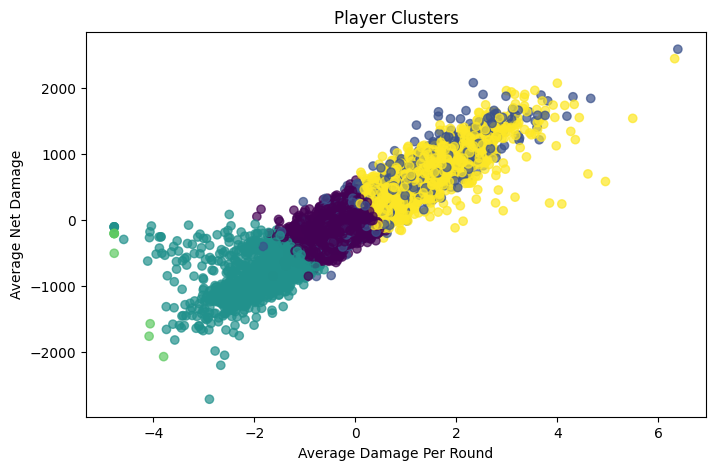

In [58]:
plt.figure(figsize=(8, 5))
plt.scatter(
    player_summary['damage_per_round'],
    player_summary['net_damage'],
    c=player_summary['cluster'],
    alpha=0.7
)
plt.xlabel('Average Damage Per Round')
plt.ylabel('Average Net Damage')
plt.title('Player Clusters')
plt.show()

In [72]:
centers = kmeans.cluster_centers_
print(centers)

[[ -0.33445005  -0.09993857  -0.3453814 ]
 [  0.57510723   0.44583024   1.65943187]
 [ -1.643909    -1.53919903  -0.69177191]
 [ -4.47891837 -23.56718718  -1.18373507]
 [  0.94298039   0.62923091  -0.18128103]]


<Figure size 800x500 with 0 Axes>

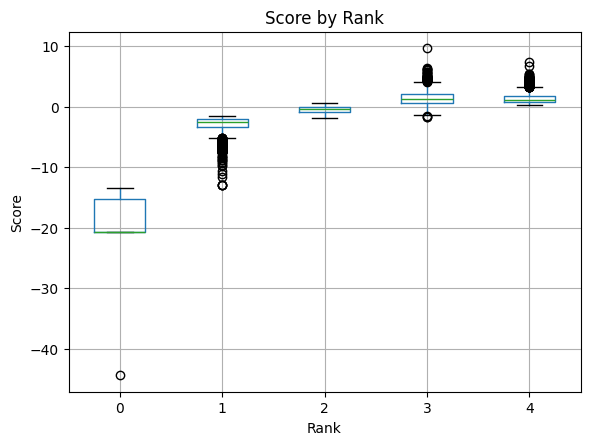

In [59]:
plt.figure(figsize=(8, 5))
player_summary.boxplot(column='score', by='rank')
plt.xlabel('Rank')
plt.ylabel('Score')
plt.title('Score by Rank')
plt.suptitle('')
plt.show()

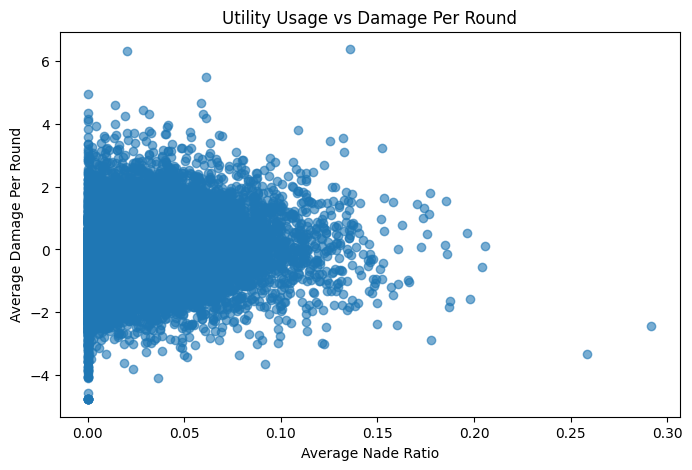

In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(player_summary['nade_ratio'], player_summary['damage_per_round'], alpha=0.6)
plt.xlabel('Average Nade Ratio')
plt.ylabel('Average Damage Per Round')
plt.title('Utility Usage vs Damage Per Round')
plt.show()

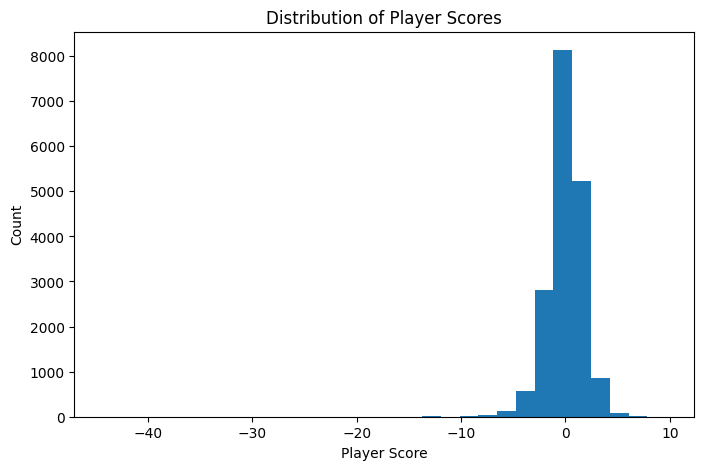

In [61]:
plt.figure(figsize=(8, 5))
plt.hist(player_summary['score'], bins=30)
plt.xlabel('Player Score')
plt.ylabel('Count')
plt.title('Distribution of Player Scores')
plt.show()